In [1]:
# ── IMPORT LIBRARIES ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── LOAD DATASET ──
df = pd.read_csv(r"C:\weather-ai-project\data\weather_raw.csv")
df['Date'] = pd.to_datetime(df['Date'])
print("Shape:", df.shape)

Shape: (145460, 23)


In [3]:
# ── TIME FEATURES ──
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

def get_season(month):
    if month in [12, 1, 2]:  return 'Summer'
    elif month in [3, 4, 5]:  return 'Autumn'
    elif month in [6, 7, 8]:  return 'Winter'
    else:                      return 'Spring'

df['Season'] = df['Month'].apply(get_season)
print(df[['Date','Month','Year','Season']].head())

        Date  Month  Year  Season
0 2008-12-01     12  2008  Summer
1 2008-12-02     12  2008  Summer
2 2008-12-03     12  2008  Summer
3 2008-12-04     12  2008  Summer
4 2008-12-05     12  2008  Summer


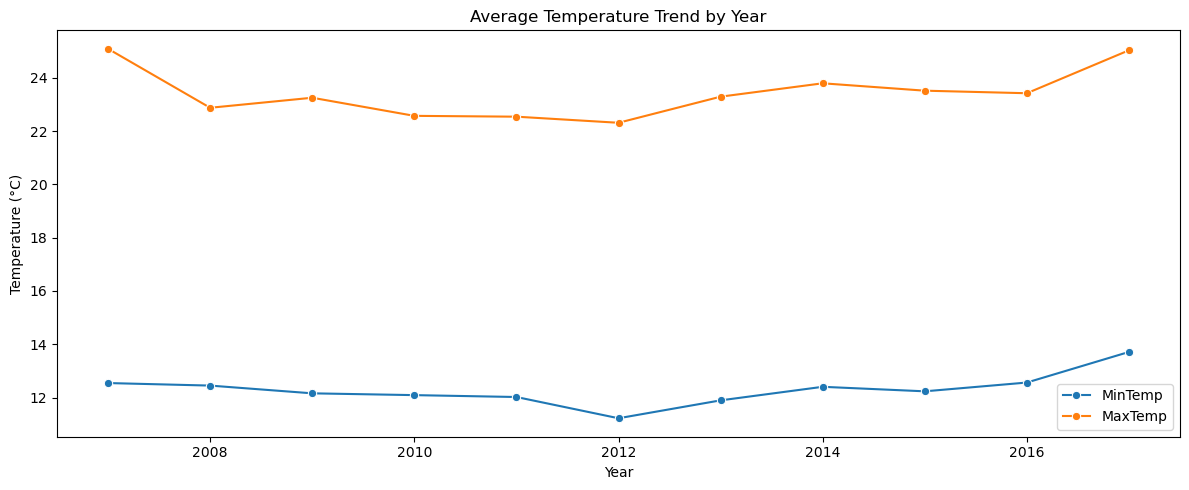

In [4]:
# ── TEMPERATURE TREND BY YEAR ──
temp_trend = df.groupby('Year')[['MinTemp','MaxTemp']].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=temp_trend, x='Year', y='MinTemp', label='MinTemp', marker='o')
sns.lineplot(data=temp_trend, x='Year', y='MaxTemp', label='MaxTemp', marker='o')
plt.title('Average Temperature Trend by Year')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

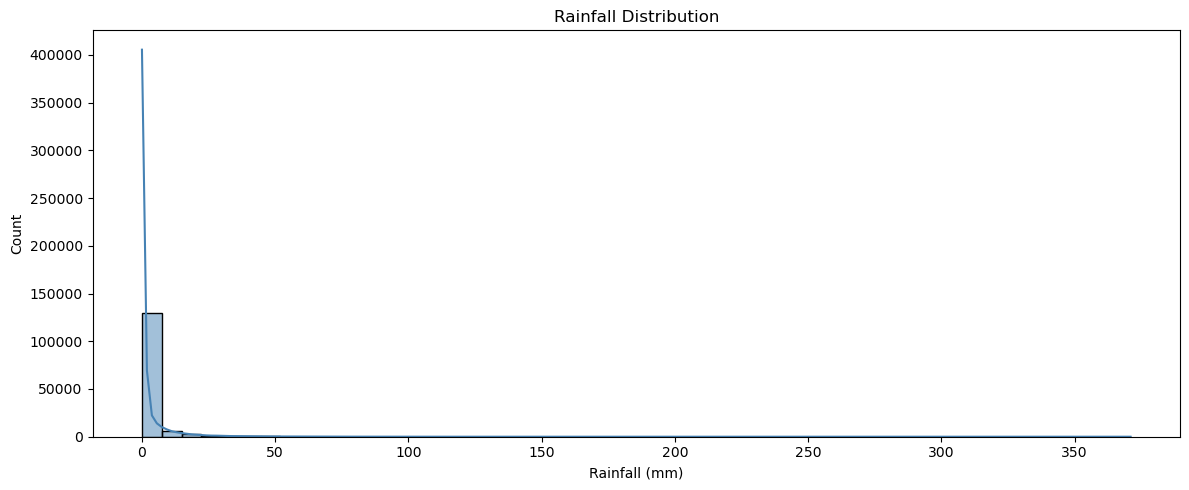

In [5]:
# ── RAINFALL DISTRIBUTION ──
plt.figure(figsize=(12,5))
sns.histplot(df['Rainfall'].dropna(), bins=50, kde=True, color='steelblue')
plt.title('Rainfall Distribution')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

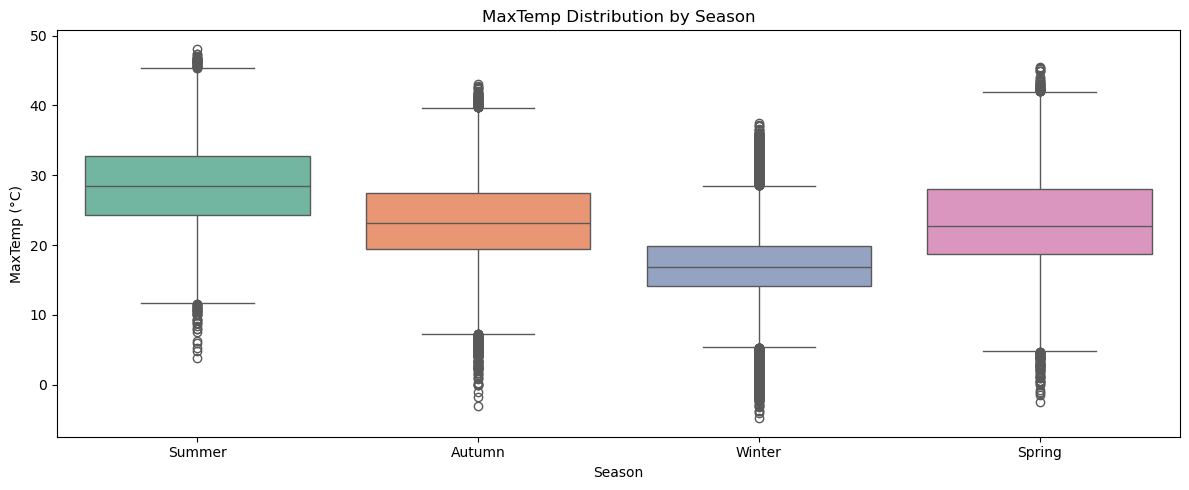

In [6]:
# ── SEASONAL ANALYSIS ──
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='Season', y='MaxTemp', 
            order=['Summer','Autumn','Winter','Spring'],
            palette='Set2')
plt.title('MaxTemp Distribution by Season')
plt.xlabel('Season')
plt.ylabel('MaxTemp (°C)')
plt.tight_layout()
plt.show()

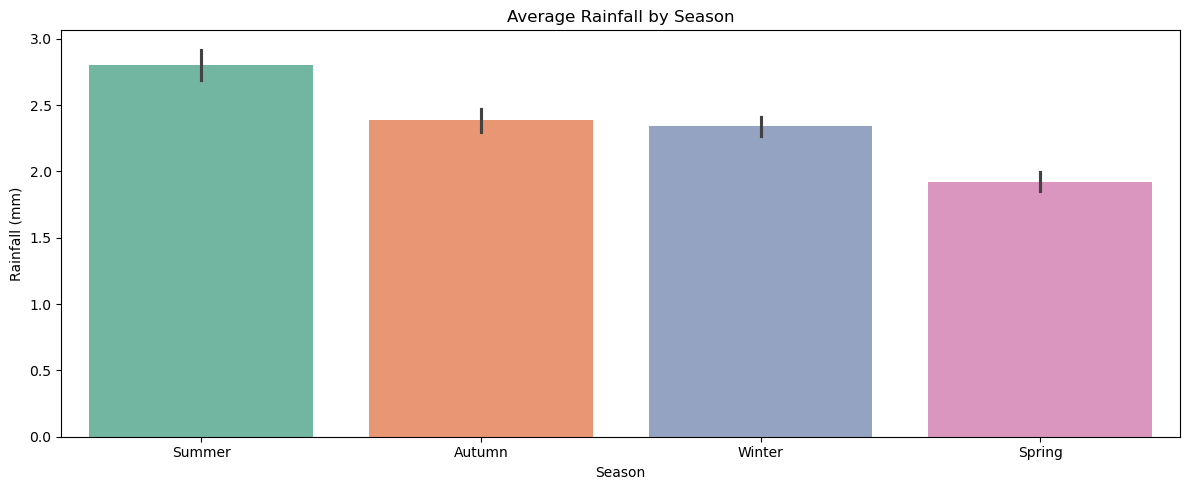

In [7]:
# ── RAINFALL BY SEASON ──
plt.figure(figsize=(12,5))
sns.barplot(data=df, x='Season', y='Rainfall',
            order=['Summer','Autumn','Winter','Spring'],
            palette='Set2', estimator='mean')
plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.show()

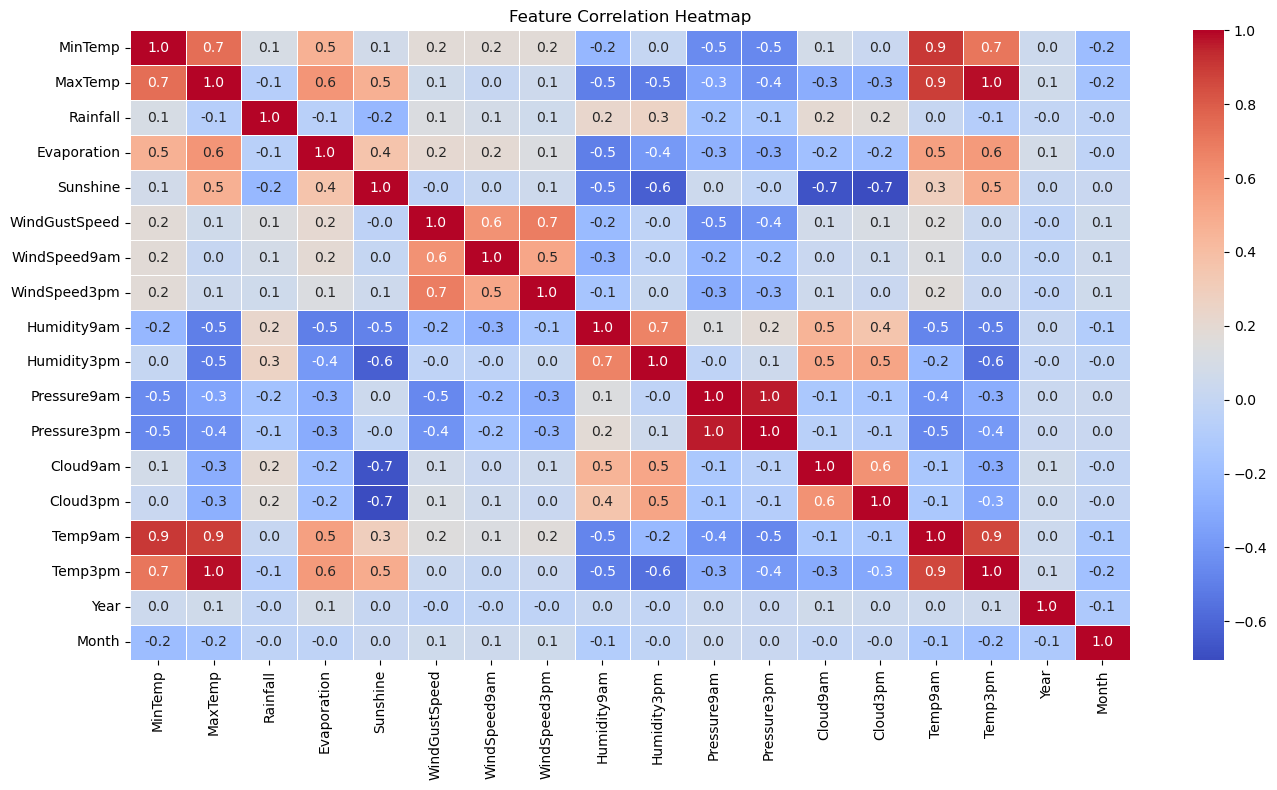

In [8]:
# ── CORRELATION HEATMAP ──
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, fmt='.1f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

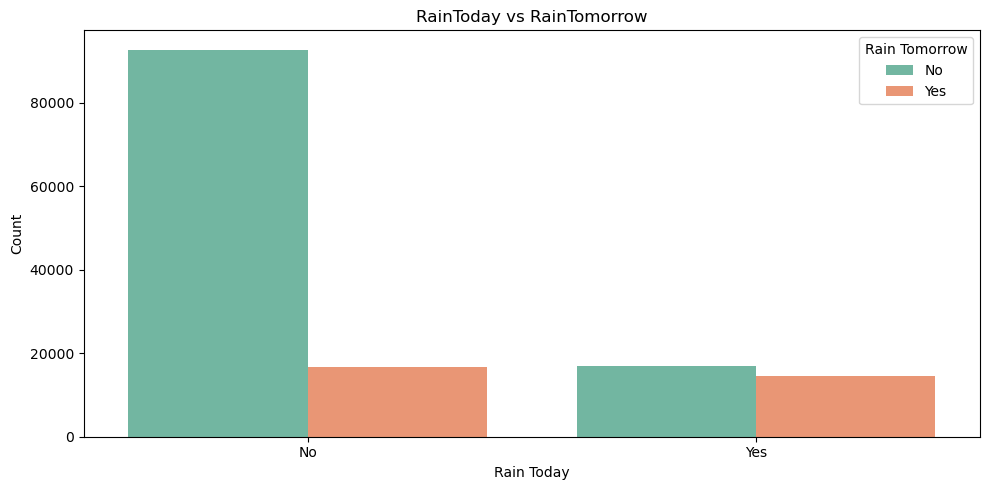

In [9]:
# ── RAIN TODAY VS RAIN TOMORROW ──
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='RainToday', hue='RainTomorrow', palette='Set2')
plt.title('RainToday vs RainTomorrow')
plt.xlabel('Rain Today')
plt.ylabel('Count')
plt.legend(title='Rain Tomorrow')
plt.tight_layout()
plt.show()

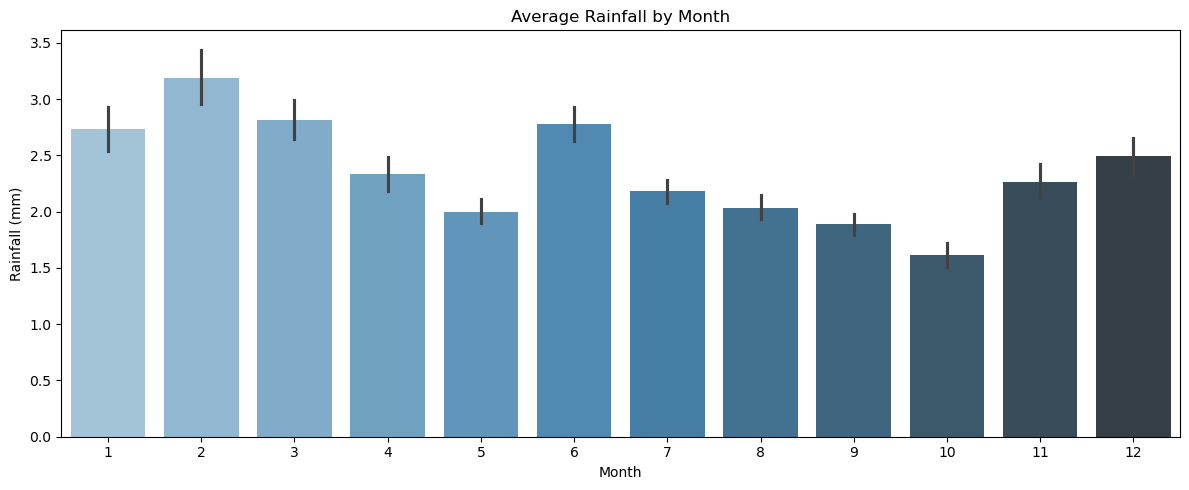

In [10]:
# ── MONTHLY RAINFALL COMPARISON ──
plt.figure(figsize=(12,5))
sns.barplot(data=df, x='Month', y='Rainfall', 
            estimator='mean', palette='Blues_d')
plt.title('Average Rainfall by Month')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.show()

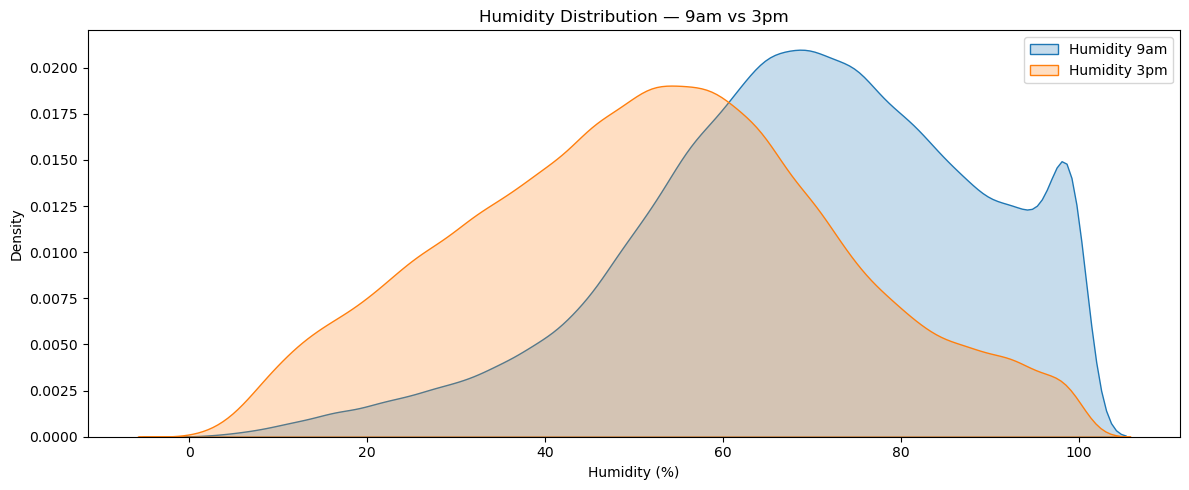

In [11]:
# ── HUMIDITY COMPARISON ──
plt.figure(figsize=(12,5))
sns.kdeplot(df['Humidity9am'].dropna(), label='Humidity 9am', fill=True)
sns.kdeplot(df['Humidity3pm'].dropna(), label='Humidity 3pm', fill=True)
plt.title('Humidity Distribution — 9am vs 3pm')
plt.xlabel('Humidity (%)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

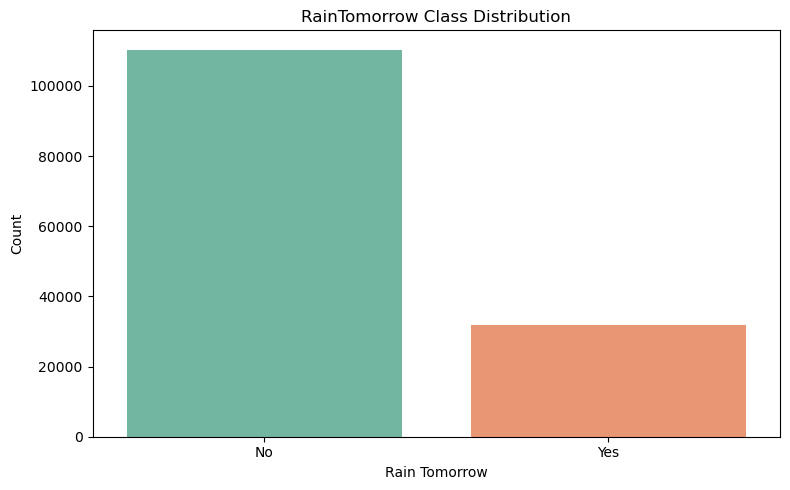

In [12]:
# ── RAINTOMORROW CLASS COUNT ──
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='RainTomorrow', palette='Set2')
plt.title('RainTomorrow Class Distribution')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

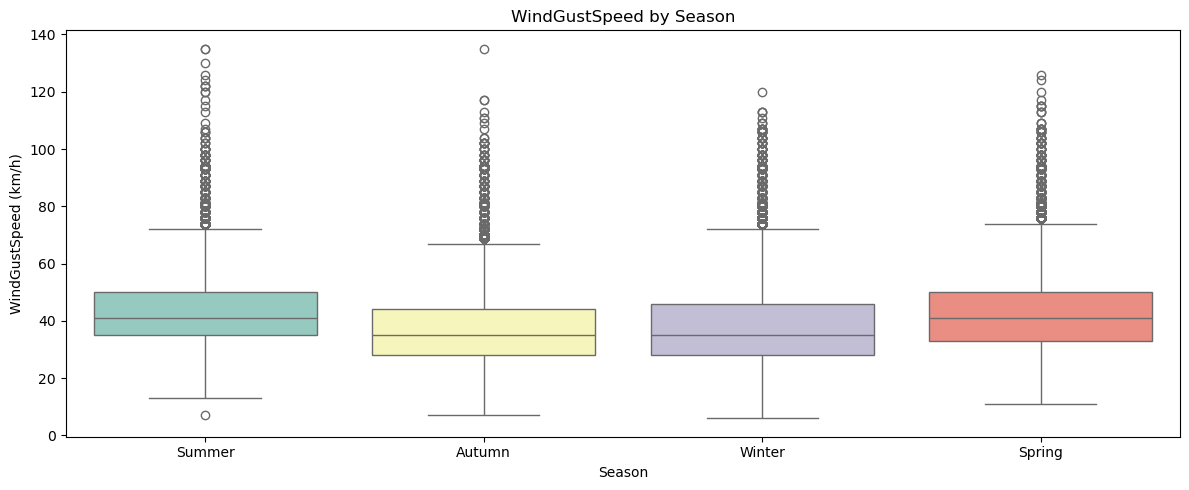

In [13]:
# ── WINDGUSTSPEED BY SEASON ──
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='Season', y='WindGustSpeed',
            order=['Summer','Autumn','Winter','Spring'],
            palette='Set3')
plt.title('WindGustSpeed by Season')
plt.xlabel('Season')
plt.ylabel('WindGustSpeed (km/h)')
plt.tight_layout()
plt.show()

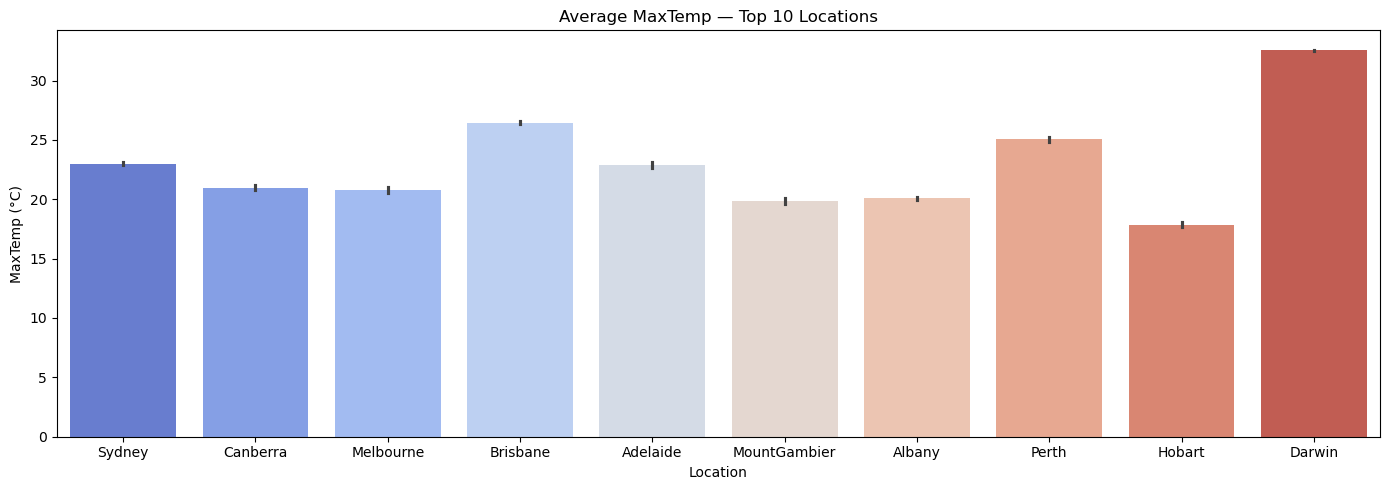

In [14]:
# ── TEMP BY TOP 10 LOCATIONS ──
top10 = df['Location'].value_counts().head(10).index
plt.figure(figsize=(14,5))
sns.barplot(data=df[df['Location'].isin(top10)],
            x='Location', y='MaxTemp', palette='coolwarm')
plt.title('Average MaxTemp — Top 10 Locations')
plt.xlabel('Location')
plt.ylabel('MaxTemp (°C)')
plt.tight_layout()
plt.show()

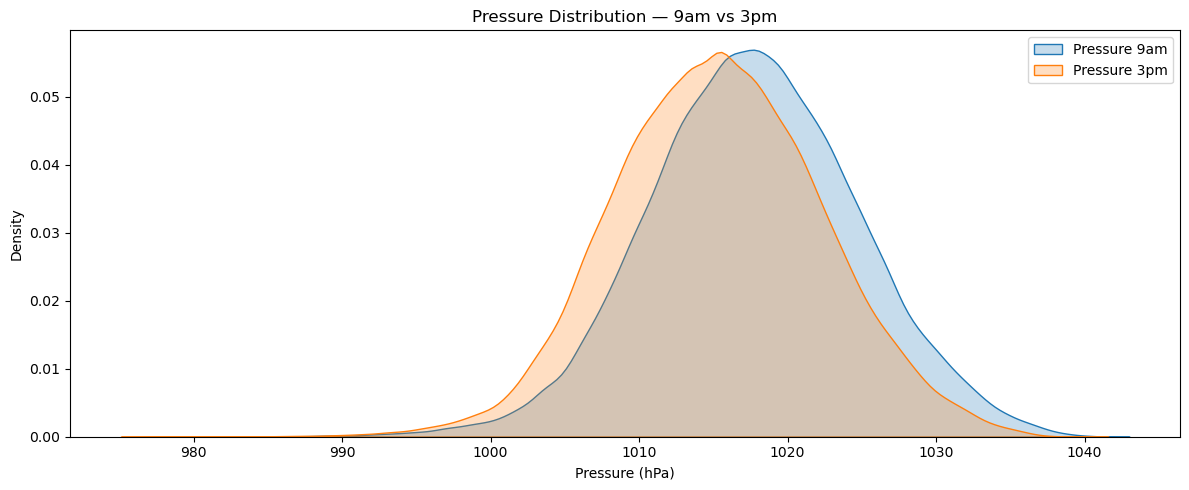

In [15]:
# ── PRESSURE COMPARISON ──
plt.figure(figsize=(12,5))
sns.kdeplot(df['Pressure9am'].dropna(), label='Pressure 9am', fill=True)
sns.kdeplot(df['Pressure3pm'].dropna(), label='Pressure 3pm', fill=True)
plt.title('Pressure Distribution — 9am vs 3pm')
plt.xlabel('Pressure (hPa)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

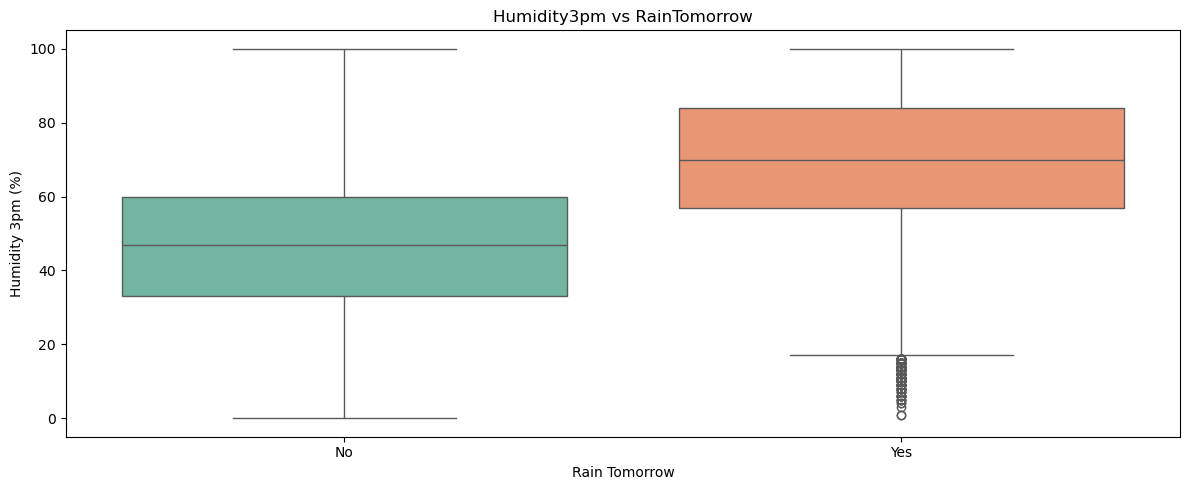

In [16]:
# ── RAINTOMORROW VS HUMIDITY3PM ──
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='RainTomorrow', y='Humidity3pm', palette='Set2')
plt.title('Humidity3pm vs RainTomorrow')
plt.xlabel('Rain Tomorrow')
plt.ylabel('Humidity 3pm (%)')
plt.tight_layout()
plt.show()

In [17]:
# ── SAVE DATA ──
df.to_csv(r"C:\weather-ai-project\data\weather_eda.csv", index=False)
print("Saved:", df.shape)

Saved: (145460, 26)
